# NSE Risk Desk | Market Risk System
### 5-Stock NSE Equity Portfolio | 2018–2024 | 99% Confidence Level

A end-to-end portfolio market risk system covering VaR, Expected Shortfall, Risk Decomposition, Stress Testing, and Excel Dashboard output.

**Portfolio:** Reliance Industries | TCS | HDFC Bank | Infosys | ITC  
**Author:** Yusuf Sayeed | FRM Part I (Q1) | FMVA  
**GitHub:** [github.com/Yusuf-Sayeed/Market-risk-models](https://github.com/Yusuf-Sayeed/Market-risk-models)

In [40]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import os

import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

## Module 1 | Data & Portfolio Construction

Pulls historical adjusted close prices from Yahoo Finance, computes daily log returns `rₜ = ln(Pₜ/Pₜ₋₁)`, and constructs a weighted portfolio return series.

**Why log returns?** Time-additive and better statistical properties for risk modelling than simple returns.

In [41]:
TICKERS = {
    "RELIANCE.NS": "Reliance Industries",
    "TCS.NS":      "Tata Consultancy Services",
    "HDFCBANK.NS": "HDFC Bank",
    "INFY.NS":     "Infosys",
    "ITC.NS":      "ITC",
}

WEIGHTS = np.array([0.20, 0.20, 0.20, 0.20, 0.20])

START_DATE = "2018-01-01"
END_DATE   = "2024-12-31"

In [42]:
def fetch_prices():
    
    raw_data = yf.download(list(TICKERS.keys()), start = START_DATE, end = END_DATE, progress = False)
    
    prices = raw_data.Close.copy()
    prices.columns = [TICKERS[t] for t in prices.columns]
    prices.dropna(how = "all", inplace = True)
    
    print(f"Downloaded {len(prices)} Trading Days")
    
    return prices

In [43]:
def compute_log_returns(prices):

    # Log returns: time-additive and better distributional properties than simple returns
    log_returns = np.log(prices / prices.shift(1)).dropna()
    
    return log_returns

In [44]:
def compute_portfolio_returns(log_returns, asset_weights):
    
    portfolio = log_returns.dot(asset_weights)
    portfolio.name = "Portfolio"
    
    return portfolio

In [45]:
def load_portfolio():
    
    prices = fetch_prices()
    
    log_returns = compute_log_returns(prices)
    
    portfolio_returns = compute_portfolio_returns(log_returns, WEIGHTS)
    
    return prices, log_returns, portfolio_returns, WEIGHTS

## Module 2 | Value at Risk Engine

Three VaR methodologies implemented and compared at 99% confidence, 1-day horizon:

| Method | Key Assumption |
|--------|---------------|
| Historical Simulation | No distributional assumption, uses actual returns |
| Parametric | Normal distribution |
| Monte Carlo | Student's t-distribution (df=6) captures fat tails |

In [46]:
prices, log_returns, portfolio_returns, WEIGHTS = load_portfolio()
conf_lvl = 0.99
simulations = 10000

Downloaded 1726 Trading Days


In [47]:
def historical_var(portfolio_returns, conf_lvl = 0.99):
    
    var = -(np.percentile(portfolio_returns, (1 -  conf_lvl)*100))
    
    return var

In [48]:
def parametric_var(portfolio_returns, conf_lvl = 0.99):
    
    mean_returns = portfolio_returns.mean()
    std_returns = portfolio_returns.std()
    z_value = stats.norm.ppf(1 - conf_lvl)
    
    var = -(mean_returns + (z_value * std_returns))
    
    return var

In [49]:
def monte_carlo_var(portfolio_returns, simulations = 10000, conf_lvl = 0.99, df = 6):
    
    mean_returns = portfolio_returns.mean()
    std_returns = portfolio_returns.std()

    np.random.seed(123)
    simulated_returns = mean_returns + (std_returns * np.random.standard_t(df, size = simulations))
    
    var = -(np.percentile(simulated_returns, (1 - conf_lvl) * 100))
    
    return var

In [50]:
h_var = historical_var(portfolio_returns, conf_lvl)
p_var= parametric_var(portfolio_returns, conf_lvl)
monte_var = monte_carlo_var(portfolio_returns, simulations, conf_lvl,)

print("=" * 25)

print(f"Parametric VaR:  {p_var * 100:.4f}% \nHistorical VaR:  {h_var * 100:.4f}% \nMonte Carlo VaR: {monte_var * 100:.4f}%" )

print("=" * 25)

Parametric VaR:  2.5160% 
Historical VaR:  3.0819% 
Monte Carlo VaR: 3.3941%


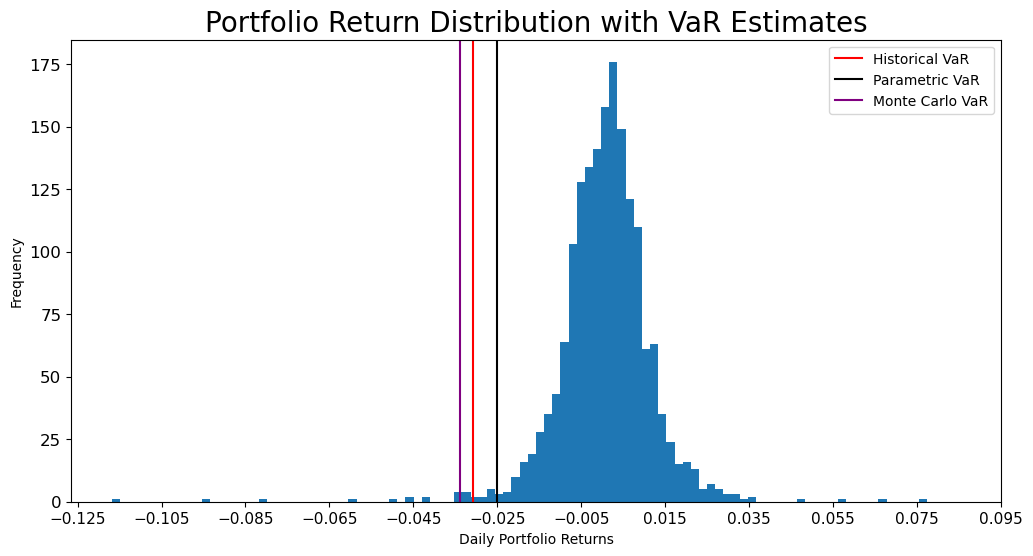

In [51]:
plt.figure(figsize = (12, 6))
plt.hist(portfolio_returns, bins = 100)
plt.axvline(-h_var, color='red', label='Historical VaR')
plt.axvline(-p_var, color='black', label='Parametric VaR')
plt.axvline(-monte_var, color='purple', label='Monte Carlo VaR')
plt.xlabel("Daily Portfolio Returns", fontsize = 10)
plt.ylabel("Frequency", fontsize = 10)
plt.xticks(np.arange(-0.125, 0.100, 0.02), fontsize=11)
plt.yticks(fontsize=12)
plt.title("Portfolio Return Distribution with VaR Estimates", fontsize = 20)
plt.legend()
plt.show()

### Backtesting — Basel II Traffic Light Test

Counts VaR exceptions over a 250-day rolling window. Basel II zones:
- 🟢 **Green** (0–4 exceptions) = model acceptable
- 🟡 **Yellow** (5–9 exceptions) = regulator scrutiny  
- 🔴 **Red** (10+ exceptions) = model rejected, capital penalty

In [52]:
def get_zone(breaches):
    
    if breaches <= 4:
        return "🟢 Green"
    elif breaches <= 9:
        return "🟡 Yellow"
    else:
        return "🔴 Red"

In [53]:
def backtest_var(portfolio_returns, h_var, p_var, monte_var, window = 250):
    
    var_estimates = {
    "Historical":  h_var,
    "Parametric":  p_var,
    "Monte Carlo": monte_var,
    }

    print("=" * 40)

    # Basel II: 250 trading days = 1 year lookback window
    for name, var in var_estimates.items():
        breaches = (portfolio_returns[-window:] < -var).sum()
        zone = get_zone(breaches)
        print(f"{name} VaR: {breaches} breaches = {zone}")

    print("=" * 40)

In [54]:
backtest_var(portfolio_returns, h_var, p_var, monte_var)

Historical VaR: 1 breaches = 🟢 Green
Parametric VaR: 2 breaches = 🟢 Green
Monte Carlo VaR: 0 breaches = 🟢 Green


## Module 3 | Expected Shortfall (CVaR)

ES measures the **average loss on days that breach VaR** — answering not just *where* the tail starts, but *how bad* it gets.

Under **Basel III / FRTB**, 97.5% ES replaced 99% VaR as the primary regulatory risk metric. ES is more sensitive to tail severity and harder to game.

`ES = −mean(rₜ | rₜ < −VaR)`

In [55]:
def historical_es(portfolio_returns, conf_lvl = 0.99):
    
    h_var = historical_var(portfolio_returns, conf_lvl)
    
    es = -(portfolio_returns.loc[portfolio_returns < -h_var]).mean()
    
    return es

In [56]:
def parametric_es(portfolio_returns, conf_lvl = 0.99):
    
    mean_returns = portfolio_returns.mean()
    std_returns = portfolio_returns.std()
    z = stats.norm.ppf(1 - conf_lvl)
    
    es = mean_returns - (std_returns *  np.exp(-(z ** 2) / 2)) / ((1 - conf_lvl) * np.sqrt(2 * np.pi))
    
    return -es

In [57]:
def monte_carlo_es(portfolio_returns, conf_lvl = 0.99, df = 6, simulations = 10000):
    
    mean_returns = portfolio_returns.mean()
    std_returns = portfolio_returns.std()
    
    monte_var = monte_carlo_var(portfolio_returns, simulations, conf_lvl)
    
    np.random.seed(123)
    # t-distribution (df=6): fatter tails than normal, better reflects equity return behaviour
    simulated_returns = mean_returns + (std_returns * np.random.standard_t(df, size = simulations))
    
    es = -(simulated_returns[simulated_returns < -monte_var]).mean()
    
    return es

In [58]:
p_es = parametric_es(portfolio_returns, conf_lvl)
h_es = historical_es(portfolio_returns, conf_lvl)
monte_es = monte_carlo_es(portfolio_returns, conf_lvl = 0.99, df = 6, simulations = 10000)

In [59]:
print("=" * 25)

print(f"Parametric VaR:   {p_var * 100:.4f}% \nHistorical VaR:   {h_var * 100:.4f}% \nMonte Carlo VaR:  {monte_var * 100:.4f}%" )

print("-" * 25)

print(f"Parametric ES:    {p_es * 100:.4f}% \nHistorical ES:    {h_es * 100:.4f}% \nMonte Carlo ES:   {monte_es * 100:.4f}%" )

print("=" * 25)

Parametric VaR:   2.5160% 
Historical VaR:   3.0819% 
Monte Carlo VaR:  3.3941%
-------------------------
Parametric ES:    2.8917% 
Historical ES:    4.8781% 
Monte Carlo ES:   4.1608%


## Module 4 | Risk Decomposition

Decomposes total portfolio VaR into per-position contributions using the covariance matrix.

- **Marginal VaR:** Rate of change of portfolio VaR per unit increase in a position: `MVaRᵢ = z · (Σw)ᵢ / σₚ`
- **Component VaR:** Each stock's actual VaR contribution: `CVaRᵢ = wᵢ · MVaRᵢ`
- **Key property:** Component VaRs sum exactly to total portfolio VaR — enabling risk budgeting and limit allocation

In [60]:
def risk_decomposition(log_returns, asset_weights, conf_lvl = 0.99):

    cov_matrix = log_returns.cov()
    port_vol = np.sqrt(asset_weights @ cov_matrix @ asset_weights)
    z = stats.norm.ppf(1 - conf_lvl)

    # Cholesky decomposition: Σw gives covariance of each stock with the portfolio
    marginal_var = abs(z) * (cov_matrix @ asset_weights) / port_vol
    
    # Component VaR additivity: sum(CVaR_i) = Portfolio VaR
    component_var = asset_weights * marginal_var
    comp_var_contribution_percent = component_var / component_var.sum()

    print("=" * 55)
    print("               RISK DECOMPOSITION SUMMARY")
    print("=" * 55)
    print(f"{'Stock':<28} {'MVaR':>8}  {'CVaR':>8}  {'CVaR %':>8}")
    print("-" * 55)

    for stock in log_returns.columns:
        print(f"  {stock:<28} {marginal_var[stock]:>7.2%}  {component_var[stock]:>7.2%}  {comp_var_contribution_percent[stock]:>7.2%}")

    print("-" * 55)
    print(f"         {'Total Portfolio VaR':<28} {component_var.sum():>7.2%}")
    print("=" * 55)

    return marginal_var, component_var, comp_var_contribution_percent

In [61]:
marginal_var, component_var, comp_var_contribution_percent = risk_decomposition(log_returns, WEIGHTS)

               RISK DECOMPOSITION SUMMARY
Stock                            MVaR      CVaR    CVaR %
-------------------------------------------------------
  HDFC Bank                      2.43%    0.49%   18.82%
  Infosys                        2.90%    0.58%   22.47%
  ITC                            2.08%    0.42%   16.12%
  Reliance Industries            2.97%    0.59%   23.01%
  Tata Consultancy Services      2.52%    0.50%   19.58%
-------------------------------------------------------
         Total Portfolio VaR            2.58%


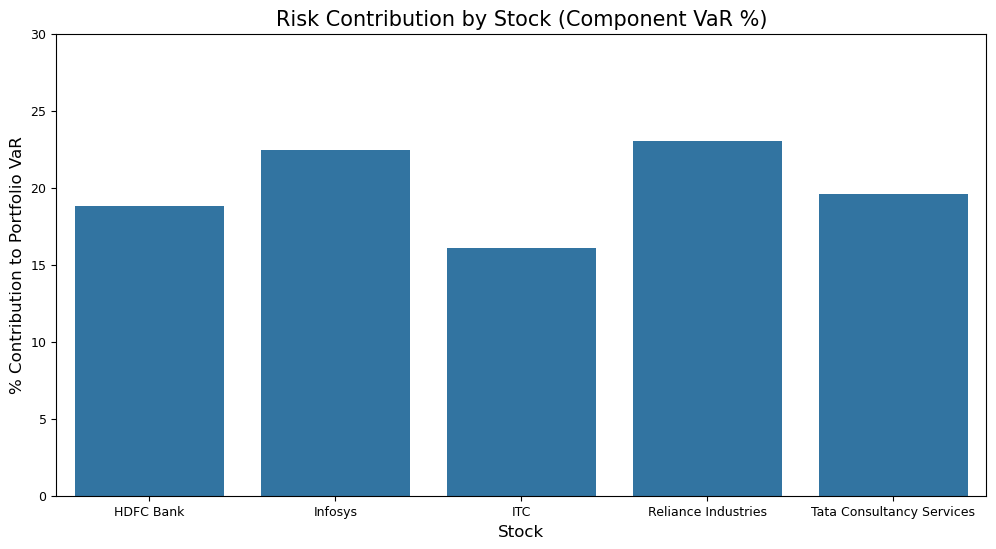

In [62]:
plt.figure(figsize = (12, 6))
sns.barplot(x = comp_var_contribution_percent.index, y = comp_var_contribution_percent.values * 100)
plt.title("Risk Contribution by Stock (Component VaR %)", fontsize = 15)
plt.xlabel("Stock", fontsize = 12)
plt.ylabel("% Contribution to Portfolio VaR", fontsize = 12)
plt.yticks(np.arange(0, 35, 5), fontsize = 9)
plt.xticks(fontsize = 9)
plt.show()

## Module 5 | Stress Testing & Scenario Analysis

VaR captures statistical risk under normal conditions. Stress testing measures P&L impact under specific extreme scenarios.

**Historical scenarios:** COVID-19 crash (Feb to Mar 2020), 2022 Rate shock (Jun to Oct 2022)  
**Hypothetical scenarios:** Nifty −10%, IT sector selloff −15%, Banking crisis −20% (HDFC Bank)

In [63]:
scenarios = {
    "COVID Crash" : ("2020-02-01", "2020-03-31"),
    "Rate Shock 2022": ("2022-06-01", "2022-10-31")
    }

In [64]:
def stress_test_historical(log_returns, asset_weights, scenarios):

    print("=" * 50)
    print("         HISTORICAL STRESS TEST RESULTS")
    
    for event, (start, end) in scenarios.items():
        event_returns = log_returns.loc[start : end]
        scenario_pnl = compute_portfolio_returns(event_returns, asset_weights).sum()
        if scenario_pnl < 0:
            print(f"{event} portfolio returns:    {scenario_pnl:.2%} 🔴")
        else:
            print(f"{event} portfolio returns:  {scenario_pnl:.2%} 🟢")
    
    print("=" * 50)

In [65]:
stress_test_historical(log_returns, WEIGHTS, scenarios)

         HISTORICAL STRESS TEST RESULTS
COVID Crash portfolio returns:    -24.34% 🔴
Rate Shock 2022 portfolio returns:  5.71% 🟢


In [66]:
hypothetical_scenarios = {
    "Nifty (-10% Shock)":        {"Reliance Industries": -0.10, "Tata Consultancy Services": -0.10, 
                                 "HDFC Bank": -0.10, "Infosys": -0.10, "ITC": -0.10},
    "IT Sector (Selloff -15%)":  {"Tata Consultancy Services": -0.15, "Infosys": -0.15},
    "Banking Crisis":          {"HDFC Bank": -0.20},
    }

In [67]:
def stress_test_hypothetical(hypothetical_scenarios, log_returns, asset_weights):
    
    print("=" * 50)
    print("     HYPOTHETICAL STRESS TEST RESULTS")

    tickers = log_returns.columns.tolist()
    
    for scenario_name, shocks in hypothetical_scenarios.items():
        pnl = 0
        for stock in tickers:
            shock = shocks.get(stock, 0)
            pnl += shock * asset_weights[tickers.index(stock)] 
        if pnl < 0:
            print(f"{scenario_name} returns:    {pnl:.2%} 🔴")
        else:
            print(f"{scenario_name} portfolio returns:  {pnl:.2%} 🟢")
    
    print("=" * 50)

In [68]:
stress_test_hypothetical(hypothetical_scenarios, log_returns, WEIGHTS)

     HYPOTHETICAL STRESS TEST RESULTS
Nifty (-10% Shock) returns:    -10.00% 🔴
IT Sector (Selloff -15%) returns:    -6.00% 🔴
Banking Crisis returns:    -4.00% 🔴


## Module 6 | Excel Risk Dashboard

Auto-generates a professional Excel dashboard consolidating all outputs using `openpyxl`. Saved to `outputs/risk_dashboard.xlsx`.

**Sheets:** Summary | Risk Decomposition | Stress Testing | Backtesting

In [69]:
# Create workbook

wb = openpyxl.Workbook()
ws_summary = wb.active
ws_summary.title = "Summary"

In [70]:
# Dashboard

ws_summary["A1"] = "Portfolio Market Risk Dashboard"
ws_summary["A1"].font = Font(bold=True, size=16)
ws_summary["A2"] = "5-Stock NSE Equity Portfolio | 2018–2024 | 99% Confidence"
ws_summary["A4"] = "Value at Risk (99%, 1-Day)"
ws_summary["A4"].font = Font(bold=True)
ws_summary["A5"] = "Method"
ws_summary["B5"] = "VaR"
ws_summary["C5"] = "ES"

for cell in ["A5", "B5", "C5"]:
    ws_summary[cell].font = Font(bold=True)

ws_summary["A6"] = "Historical"
ws_summary["B6"] = round(h_var * 100, 4)
ws_summary["C6"] = round(h_es * 100, 4)

ws_summary["A7"] = "Parametric"
ws_summary["B7"] = round(p_var * 100, 4)
ws_summary["C7"] = round(p_es * 100, 4)

ws_summary["A8"] = "Monte Carlo"
ws_summary["B8"] = round(monte_var * 100, 4)
ws_summary["C8"] = round(monte_es * 100, 4)

ws_summary.column_dimensions["A"].width = 30
ws_summary.column_dimensions["B"].width = 12
ws_summary.column_dimensions["C"].width = 12
ws_summary.column_dimensions["D"].width = 22

for row in range(6, 9):
    ws_summary[f"B{row}"].number_format = '0.0000"%"'
    ws_summary[f"C{row}"].number_format = '0.0000"%"'

header_fill = PatternFill(start_color="1F4E79", end_color="1F4E79", fill_type="solid")
for cell in ["A5", "B5", "C5"]:
    ws_summary[cell].fill = header_fill
    ws_summary[cell].font = Font(bold=True, color="FFFFFF")

In [71]:
# Risk decomposition block

ws_summary["A10"] = "Risk Decomposition Section"
ws_summary["A10"].font = Font(bold=True, size=16)
ws_summary["A11"] = "Stock"
ws_summary["B11"] = "Marginal VaR"
ws_summary["C11"] = "Component VaR"
ws_summary["D11"] = "CVaR % Contribution"

for cell in ["A11", "B11", "C11", "D11"]:
    ws_summary[cell].fill = header_fill
    ws_summary[cell].font = Font(bold=True, color="FFFFFF")

for i, stock in enumerate(marginal_var.index):
    row = 12 + i
    ws_summary[f"A{row}"] = stock
    ws_summary[f"B{row}"] = marginal_var[stock]
    ws_summary[f"C{row}"] = component_var[stock]
    ws_summary[f"D{row}"] = comp_var_contribution_percent[stock] * 100

for row in range(12, 17):
    ws_summary[f"B{row}"].number_format = '0.0000"%"'
    ws_summary[f"C{row}"].number_format = '0.0000"%"'
    ws_summary[f"D{row}"].number_format = '0.0000"%"'

In [72]:
# Stress testing block

ws_summary["A18"] = "Stress Testing"
ws_summary["A18"].font = Font(bold=True, size=16)

ws_summary["A19"] = "Scenario"
ws_summary["B19"] = "P&L"

for cell in ["A19", "B19"]:
    ws_summary[cell].fill = header_fill
    ws_summary[cell].font = Font(bold=True, color="FFFFFF")

row = 20
for event, (start, end) in scenarios.items():
    event_returns = log_returns.loc[start:end]
    pnl = compute_portfolio_returns(event_returns, WEIGHTS).sum()
    ws_summary[f"A{row}"] = event
    ws_summary[f"B{row}"] = pnl * 100
    ws_summary[f"B{row}"].number_format = '0.00"%"'
    row += 1

for scenario_name, shocks in hypothetical_scenarios.items():
    pnl = 0
    for stock in log_returns.columns.tolist():
        pnl += shocks.get(stock, 0) * WEIGHTS[log_returns.columns.tolist().index(stock)]
    ws_summary[f"A{row}"] = scenario_name
    ws_summary[f"B{row}"] = pnl * 100
    ws_summary[f"B{row}"].number_format = '0.00"%"'
    row += 1

In [73]:
# Backtesting block

ws_summary["A26"] = "Backtesting"
ws_summary["A26"].font = Font(bold=True, size=16)

breaches = {
    "Historical":  int((portfolio_returns[-250:] < -h_var).sum()),
    "Parametric":  int((portfolio_returns[-250:] < -p_var).sum()),
    "Monte Carlo": int((portfolio_returns[-250:] < -monte_var).sum()),
}

ws_summary["A27"] = "Method"
ws_summary["B27"] = "Breaches"
ws_summary["C27"] = "Zone"

for cell in ["A27", "B27", "C27"]:
    ws_summary[cell].fill = header_fill
    ws_summary[cell].font = Font(bold=True, color="FFFFFF")

row = 28
for method, breach_count in breaches.items():
    ws_summary[f"A{row}"] = method
    ws_summary[f"B{row}"] = breach_count
    ws_summary[f"C{row}"] = get_zone(breach_count)
    row += 1

In [74]:
# Create outputs directory if it doesn't exist and save the workbook

os.makedirs("outputs", exist_ok=True)
wb.save("outputs/risk_dashboard.xlsx")